In [1]:
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab import imshow_grid, imshowhs_grid  # For plotting results; optional
from landlab.components import BedrockLandslider  # BedrockLandslider model
from landlab.components import SpaceLargeScaleEroder  # SPACE model
from landlab.components import PriorityFloodFlowRouter 

Create a meshgrid to plot parabolic formula

In [2]:
xvals = np.linspace(-500,500,100)
yvals = np.linspace(0,1000,100)
xv, yv = np.meshgrid(xvals,yvals)

initialize parabolic formula

In [3]:
a=0.003
b=2
c=0.0001
d=2
zv = a*(xv**b) + c*(yv**d)

add noise to array

In [4]:
noise = np.random.rand(zv.shape[0],zv.shape[1])
sim_glac = zv + noise

plot for sanity

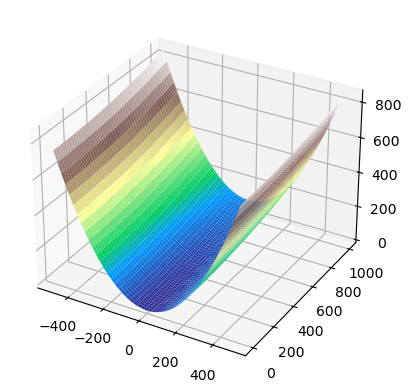

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(xv,yv,sim_glac,cmap='terrain')

get it into a raster grid

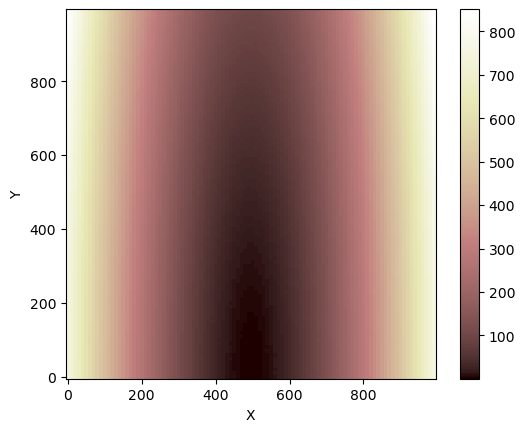

In [6]:
grid = RasterModelGrid(sim_glac.shape, 10.0)
grid.at_node['bedrock__elevation'] = sim_glac
grid.imshow('bedrock__elevation')

In [7]:
# add field 'soil__depth' to the grid
grid.add_ones("soil__depth", at="node", clobber=True)

# Add field 'bedrock__elevation' to the grid
grid.add_zeros("topographic__elevation", at="node", clobber=True)

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
grid.at_node["bedrock__elevation"][:] = grid.at_node["topographic__elevation"]
grid.at_node["topographic__elevation"][:] += grid.at_node["soil__depth"]

In [8]:
grid.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=False,
    left_is_closed=True,
    right_is_closed=True,
    top_is_closed=True,
)

In [9]:
# Instantiate flow router
fr = PriorityFloodFlowRouter(grid, surface='topographic__elevation', flow_metric="D8", suppress_out=True)

# Instantiate SPACE model with chosen parameters
sp = SpaceLargeScaleEroder(
    grid,
    K_sed=2.5e-5,
    K_br=2.5e-5,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

/opt/tljh/user/envs/csdms/lib/python3.13/site-packages/richdem/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
# Set model timestep
timestep = 1e2  # years

# Set elapsed time to zero
elapsed_time = 0.0  # years

# Set timestep count to zero
count = 0

# Set model run time
run_time = 1e4  # years

# Array to save sediment flux values
sed_flux = np.zeros(int(run_time // timestep))

# Uplift rate in m/yr
U = 1e-3

cmap = copy.copy(mpl.colormaps["terrain"])

while elapsed_time < run_time:  # time units of years
    # Insert uplift at core nodes
    mg.at_node["bedrock__elevation"][mg.core_nodes] += U * timestep
    mg.at_node["topographic__elevation"][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )

    # Run the flow router
    fr.run_one_step()

    # Run SPACE for one time step
    sp.run_one_step(dt=timestep)

    # Add to value of elapsed time
    elapsed_time += timestep

    if np.mod(elapsed_time, 1e5) == 0:
        print("%.2f of model run completed" % (elapsed_time / run_time))
        imshow_grid(
            mg, "topographic__elevation", cmap=cmap, colorbar_label="Elevation (m)"
        )
        plt.show()

NameError: name 'copy' is not defined